<a href="https://colab.research.google.com/github/itsanil2011/ted-talk-views-prediction/blob/main/Capstone_project_Logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Ted Talk Views Prediction**

##### **Project Type**    - EDA/Regression/Supervised
##### **Contribution**    - Individual

# **Project Summary -**

**Project Summary**: TED Talk View Prediction

This project aims to predict the number of views a TED Talk video is likely to receive based on various features extracted from the TED Talk dataset. TED Talks, known for their impactful and inspiring content, span a wide variety of topics and speakers. By analyzing TED Talk data, this project explores the relationship between various attributes of TED Talks and their viewership. Understanding this relationship can help content creators, event organizers, and marketers in crafting more engaging and widely viewed talks.


# **dataset link**

click [here](https://drive.google.com/file/d/1qT8kO-wsUD6hRMDZjjFaGVKZlxUx3MBD/view?usp=sharing) to access dataset

# **GitHub Link -**

click [here](https://www.github.com/itsanil2011) to access project

# **Problem Statement**


**The ultimate goal of the project is to predict the views column, which represents the number of views a TED Talk is likely to receive.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### **Import Libraries**

In [104]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import StackingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings(action='ignore')

### **Dataset Loading**

In [105]:
# Load Dataset
data_file = 'drive/MyDrive/Copy of data_ted_talks.csv'
d = pd.read_csv(data_file)
df = d.copy()

### **Dataset First View**

In [106]:
# Dataset First Look
d.head()

,talk_id,title,speaker_1,all_speakers,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
0,1,Averting the climate crisis,Al Gore,{0: 'Al Gore'},{0: ['climate advocate']},{0: 'Nobel Laureate Al Gore focused the world’...,3523392,2006-02-25,2006-06-27,TED2006,en,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa...",272.0,977,"['alternative energy', 'cars', 'climate change...","{243: 'New thinking on the climate crisis', 54...",https://www.ted.com/talks/al_gore_averting_the...,With the same humor and humanity he exuded in ...,"Thank you so much, Chris. And it's truly a gre..."
1,92,The best stats you've ever seen,Hans Rosling,{0: 'Hans Rosling'},{0: ['global health expert; data visionary']},"{0: 'In Hans Rosling’s hands, data sings. Glob...",14501685,2006-02-22,2006-06-27,TED2006,en,"['ar', 'az', 'bg', 'bn', 'bs', 'cs', 'da', 'de...",628.0,1190,"['Africa', 'Asia', 'Google', 'demo', 'economic...","{2056: ""Own your body's data"", 2296: 'A visual...",https://www.ted.com/talks/hans_rosling_the_bes...,You've never seen data presented like this. Wi...,"About 10 years ago, I took on the task to teac..."
2,7,Simplicity sells,David Pogue,{0: 'David Pogue'},{0: ['technology columnist']},{0: 'David Pogue is the personal technology co...,1920832,2006-02-24,2006-06-27,TED2006,en,"['ar', 'bg', 'de', 'el', 'en', 'es', 'fa', 'fr...",124.0,1286,"['computers', 'entertainment', 'interface desi...","{1725: '10 top time-saving tech tips', 2274: '...",https://www.ted.com/talks/david_pogue_simplici...,New York Times columnist David Pogue takes aim...,"(Music: ""The Sound of Silence,"" Simon & Garfun..."
3,53,Greening the ghetto,Majora Carter,{0: 'Majora Carter'},{0: ['activist for environmental justice']},{0: 'Majora Carter redefined the field of envi...,2664069,2006-02-26,2006-06-27,TED2006,en,"['ar', 'bg', 'bn', 'ca', 'cs', 'de', 'en', 'es...",219.0,1116,"['MacArthur grant', 'activism', 'business', 'c...",{1041: '3 stories of local eco-entrepreneurshi...,https://www.ted.com/talks/majora_carter_greeni...,"In an emotionally charged talk, MacArthur-winn...",If you're here today — and I'm very happy that...
4,66,Do schools kill creativity?,Sir Ken Robinson,{0: 'Sir Ken Robinson'},"{0: ['author', 'educator']}","{0: ""Creativity expert Sir Ken Robinson challe...",65051954,2006-02-25,2006-06-27,TED2006,en,"['af', 'ar', 'az', 'be', 'bg', 'bn', 'ca', 'cs...",4931.0,1164,"['children', 'creativity', 'culture', 'dance',...","{865: 'Bring on the learning revolution!', 173...",https://www.ted.com/talks/sir_ken_robinson_do_...,Sir Ken Robinson makes an entertaining and pro...,Good morning. How are you? (Audience) Good. It...


### **Dataset Rows & Columns count**

In [107]:
# Dataset Rows & Columns count
d.shape

(4005, 19)

### **Dataset Information**

In [108]:
# Dataset Info
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4005 entries, 0 to 4004
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   talk_id         4005 non-null   int64  
 1   title           4005 non-null   object 
 2   speaker_1       4005 non-null   object 
 3   all_speakers    4001 non-null   object 
 4   occupations     3483 non-null   object 
 5   about_speakers  3502 non-null   object 
 6   views           4005 non-null   int64  
 7   recorded_date   4004 non-null   object 
 8   published_date  4005 non-null   object 
 9   event           4005 non-null   object 
 10  native_lang     4005 non-null   object 
 11  available_lang  4005 non-null   object 
 12  comments        3350 non-null   float64
 13  duration        4005 non-null   int64  
 14  topics          4005 non-null   object 
 15  related_talks   4005 non-null   object 
 16  url             4005 non-null   object 
 17  description     4005 non-null   o

### **Duplicate Values**

In [109]:
# Dataset Duplicate Value Count
df.drop_duplicates(inplace=True)

### **Missing Values/Null Values**

In [110]:
# Missing Values/Null Values Count
df.isnull().sum().sort_values()

,0
talk_id,0
title,0
speaker_1,0
views,0
available_lang,0
native_lang,0
event,0
published_date,0
duration,0
topics,0


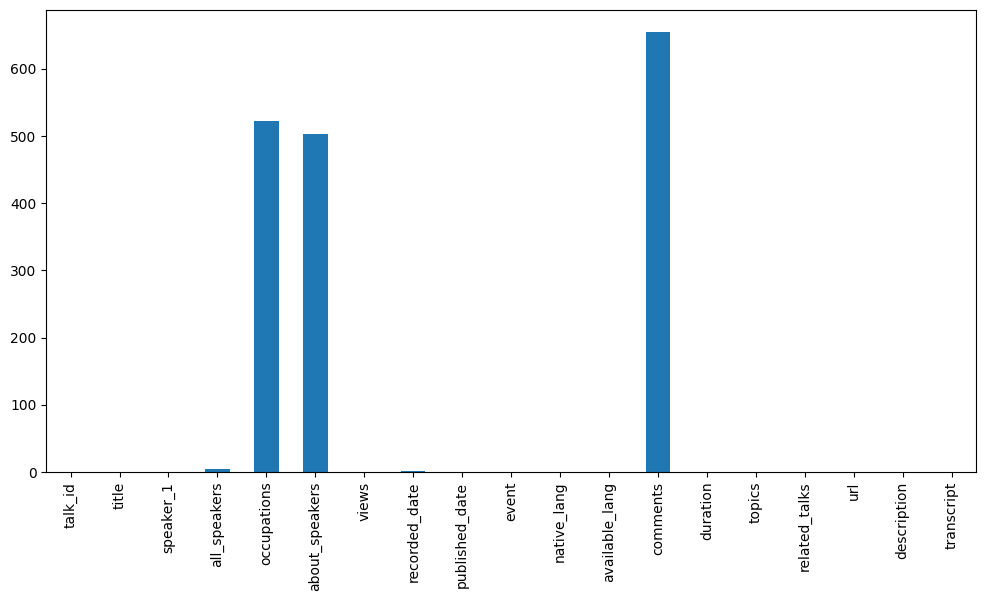

In [111]:
# Visualizing the missing values
plt.figure(figsize=(12,6))
df.isnull().sum().plot(kind='bar');

### **What did you know about your dataset?**

### Dataset having null values in following 3 columns
  - **all_speakers:**  	4
  - **occupations:** 	522
  - **about_speakers:** 	503
  - **recorded_date:** 1
  - **comments:** 	655
---

In [112]:
# we have to fill null values from comment column with 0.
df.fillna({'comments': 0}, inplace=True)

In [113]:
# we have to fill null values from occupations column with missing data.
df.fillna({'occupations': 'missing'}, inplace=True)

In [114]:
# we have to fill null values from about_speakers column with missing data.
df.fillna({'about_speakers': 'missing'}, inplace=True)

In [115]:
df.views.value_counts()

,count
views,
0,6
1968363,2
1446787,2
1454261,2
806149,2
...,...
2625338,1
727048,1
1704167,1


### **There are 6 columns in views column having zero views. We simply replace it with zero.**

In [116]:
df.views = df.views.replace(0, df.views.mean())

In [117]:
df.dropna(inplace=True)

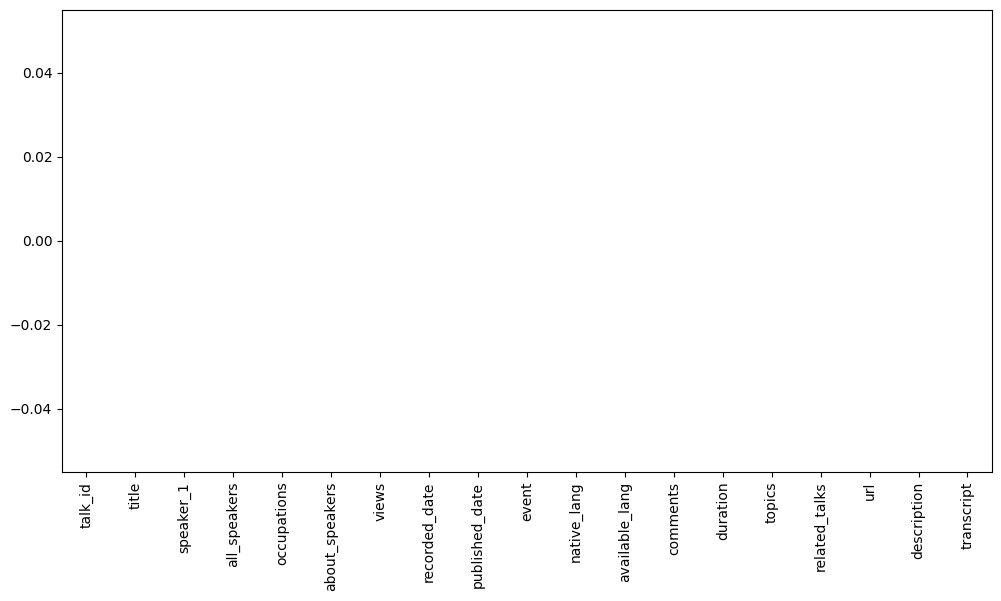

In [118]:
# Visualizing the missing values
plt.figure(figsize=(12,6))
df.isnull().sum().plot(kind='bar');

### **Now no null values in dataframe**
---
---

## ***2. Understanding Your Variables***

In [119]:
# Dataset Columns
df.columns

Index(['talk_id', 'title', 'speaker_1', 'all_speakers', 'occupations',
       'about_speakers', 'views', 'recorded_date', 'published_date', 'event',
       'native_lang', 'available_lang', 'comments', 'duration', 'topics',
       'related_talks', 'url', 'description', 'transcript'],
      dtype='object')

In [120]:
# Dataset Describe
df.describe()

,talk_id,views,comments,duration
count,4000.000000,4.000000e+03,4000.00000,4000.000000
mean,12397.454500,2.152523e+06,135.66750,723.959250
std,17425.490867,3.451848e+06,253.18078,361.788987
min,1.000000,1.000400e+04,0.00000,60.000000
25%,1250.750000,8.857095e+05,17.00000,392.750000
50%,2330.500000,1.379386e+06,68.00000,738.000000
75%,23770.500000,2.143401e+06,162.25000,973.000000
max,62794.000000,6.505195e+07,6449.00000,3922.000000


### **Variables Description**

---
**columns in the dataset** are as follows:

  - **talk_id:** A unique identifier for each TED Talk.
  - **title:** The title of the TED Talk, which often reflects the main theme of the talk.
  - **speaker_1:** The name of the main speaker of the TED Talk.
  - **all_speakers:** The names of all speakers who participated in the talk.
  - **occupations:** The professions of the speakers.
  - **about_speakers:** A brief description of the speaker(s), providing context about their background.
  - **views:** The total number of views the TED Talk has received. This is the target variable for the prediction model.
  - **recorded_date:** The date on which the talk was recorded.
  - **published_date:** The date on which the talk was made available online.
  - **event:** The event or conference where the talk was presented.
  - **native_lang:** The native language(s) of the speaker(s).
  - **available_lang:** The language(s) in which the talk is available.
  - **comments:** The number of comments the TED Talk has received.
  - **duration:** The length of the TED Talk, typically measured in minutes.
  - **topics:** A list of topics covered in the TED Talk.
  - **related_talks:** Other TED Talks related to the current one, based on theme or subject matter.
  - **url:** A direct URL to the TED Talk.
  - **description:** A brief description or summary of the TED Talk.
  - **transcript:** The full transcript of the TED Talk.
---


### **Check Unique Values for each variable.**

In [121]:
# Check Unique Values for each variable.
df.nunique()

,0
talk_id,4000
title,4000
speaker_1,3269
all_speakers,3305
occupations,2050
about_speakers,2977
views,3991
recorded_date,1333
published_date,2962
event,458


## 3. ***Data Wrangling***

### **Data Wrangling Code**

In [122]:
# Write your code to make your dataset analysis ready.
df.all_speakers.sample(4)

,all_speakers
3437,{0: 'Danielle N. Lee'}
1728,{0: 'Paul Bloom'}
3843,{0: 'Christopher Danielson'}
1151,{0: 'Frans de Waal'}


### **converted values of column all_speakers from dict to str**


In [123]:
df['all_speakers'] = df.all_speakers.apply( lambda x: list(eval(x).values()) )

In [124]:
df[['speaker_1','all_speakers']].sample(12)

,speaker_1,all_speakers
3779,Hector Lanz,[Hector Lanz]
6,Julia Sweeney,[Julia Sweeney]
2810,Brett Hennig,[Brett Hennig]
3737,David Asch,[David Asch]
1846,Cristina Domenech,[Cristina Domenech]
1311,Pankaj Ghemawat,[Pankaj Ghemawat]
214,Amy Tan,[Amy Tan]
815,Liza Donnelly,[Liza Donnelly]
3033,Alex Gendler,[Alex Gendler]
2828,Dan Kwartler,[Dan Kwartler]


#### **by executing above line of code sevral times we can conclude that _speaker1_ and _all speakers_ having exactly same value. So simply we will delete all_speakers column.**

In [125]:
df.drop(columns=['all_speakers'], inplace=True)

---

In [126]:
df.occupations.sample(5)

,occupations
3670,missing
225,{0: ['oceanographer']}
3264,missing
3621,missing
2975,missing


### **occupations column having messy data we have to clean it by converting values into plain text**

In [127]:
df.occupations = df.occupations.apply( lambda name: eval(name).get(0)[0] if name!='missing' else 'missing' )

In [128]:
df.occupations.sample(5)

,occupations
2604,retail expert
2664,designer
3968,human rights advocate
522,landscape ecologist
2728,social innovation expert


---

In [129]:
df.about_speakers.sample(5)

,about_speakers
2643,{0: 'Amar Inamdar works with businesses and en...
2435,{0: 'With astronaut eyes and ethnographer curi...
1983,"{0: ""BCG's Yves Morieux researches how corpora..."
1155,{0: 'Surgeon and public health professor by da...
3764,{0: 'Tal Danino explores the emerging frontier...


### **about_speakers column having messy data we have to clean it by converting values into plain text**

In [130]:
df.about_speakers = df.about_speakers.apply( lambda name: eval(name).get(0) if name!='missing' else 'missing' )

In [131]:
df.about_speakers.sample(5)

,about_speakers
3205,missing
2569,TED Resident Jackson Bird is using digital sto...
3326,Olympia Della Flora wants schools to think dif...
579,"As an emerging markets investor, Ravin Agrawal..."
2024,Daniel Levitin incorporates findings from neur...


---

### **converting recorded_date and published_date column into datetime format**


In [132]:
df['recorded_date'] = pd.to_datetime(df['recorded_date'])
df['published_date'] = pd.to_datetime(df['published_date'])

---

In [133]:
df.available_lang.sample(5)

,available_lang
1858,"['ar', 'bg', 'cs', 'de', 'en', 'es', 'fa', 'fr..."
2123,"['ar', 'bg', 'el', 'en', 'es', 'fa', 'fr', 'he..."
779,"['ar', 'bg', 'cs', 'da', 'de', 'el', 'en', 'es..."
658,"['ar', 'bg', 'cs', 'de', 'el', 'en', 'es', 'fa..."
362,"['ar', 'bg', 'el', 'en', 'es', 'fi', 'fr', 'he..."


### **avaliable_lang column having language codes. We can convert this column to store language count**

In [134]:
df.available_lang = df.available_lang.apply(lambda x: len(eval(x)) )

In [135]:
df.sample(3)

,talk_id,title,speaker_1,occupations,about_speakers,views,recorded_date,published_date,event,native_lang,available_lang,comments,duration,topics,related_talks,url,description,transcript
3186,23837,"How to organize, add and multiply matrices",Bill Shillito,missing,missing,385333.0,2013-03-04,2019-02-12,TED-Ed,en,18,0.0,269,"['TED-Ed', 'animation', 'economics', 'math']",{19173: 'Can you solve the Mondrian squares ri...,https://www.ted.com/talks/bill_shillito_how_to...,When you're working on a problem with lots of ...,"By now, I'm sure you know that in just about a..."
273,175,Kids can teach themselves,Sugata Mitra,education researcher,Educational researcher Sugata Mitra is the win...,1797841.0,2007-02-02,2008-08-27,LIFT 2007,en,30,182.0,1259,"['children', 'cities', 'culture', 'education',...","{1678: 'Build a School in the Cloud', 66: 'Do ...",https://www.ted.com/talks/sugata_mitra_kids_ca...,"Speaking at LIFT 2007, Sugata Mitra talks abou...","I have a tough job to do. You know, when I loo..."
2085,2427,The case for fish farming,Mike Velings,entrepreneur and conservationist,Mike Velings understands the potential for bus...,1289775.0,2015-10-10,2016-02-11,Mission Blue II,en,23,119.0,918,"['biodiversity', 'big problems', 'consumerism'...","{1373: ""The ocean's shifting baseline"", 2389: ...",https://www.ted.com/talks/mike_velings_the_cas...,We're headed towards a global food crisis: Nea...,So I come from the tallest people on the plane...


### **All manipulations**
  - converted values of column all_speakers from dict to str.
  - converted occupations column values into plain text.
  - converted about_speakers into plain text.
  - converted recorded_date column into datetime format.
  - converted recorded_date column into datetime format.

---

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

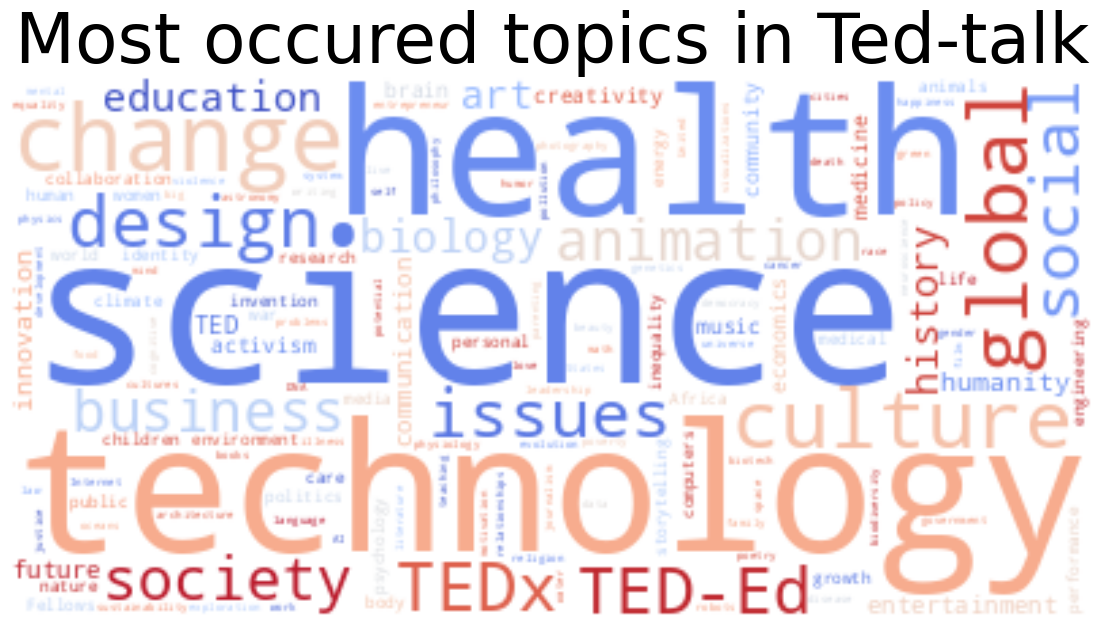

In [136]:
# for topics column
words = []
for i in df.topics.values:
  for j in i.split():
    words.append(j.replace('[', '').replace(']', '').replace("'", '').replace(',','')   )

wc = pd.Series(words).value_counts()

# Generate the word cloud with the custom mask
wordcloud = WordCloud(background_color='white',colormap='coolwarm' ).generate_from_frequencies(wc)
plt.figure(figsize=(14, 25))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most occured topics in Ted-talk', fontdict={'size': 50})
plt.axis('off');

##### **1. Why did you pick the specific chart?**
  - topics column having all string values.
  - and these string values are individual.
  - So, converting these values using column encoding will not work.
  - Thats why WordCloud is best chart for this data.

##### **2. What is/are the insight(s) found from the chart?**

following are the most occured words in Topics column
  - technology
  - science
  - health
  - change
  - global

##### **3. Will the gained insights help creating a positive business impact?**
Are there any insights that lead to negative growth? Justify with specific reason.

Following are the less occured words in topics:
  - humanity
  - creativity
  - medicine
  - children
  - innovation

In my view these topics are most important and should be included in discussion.

### **Chart - 2**

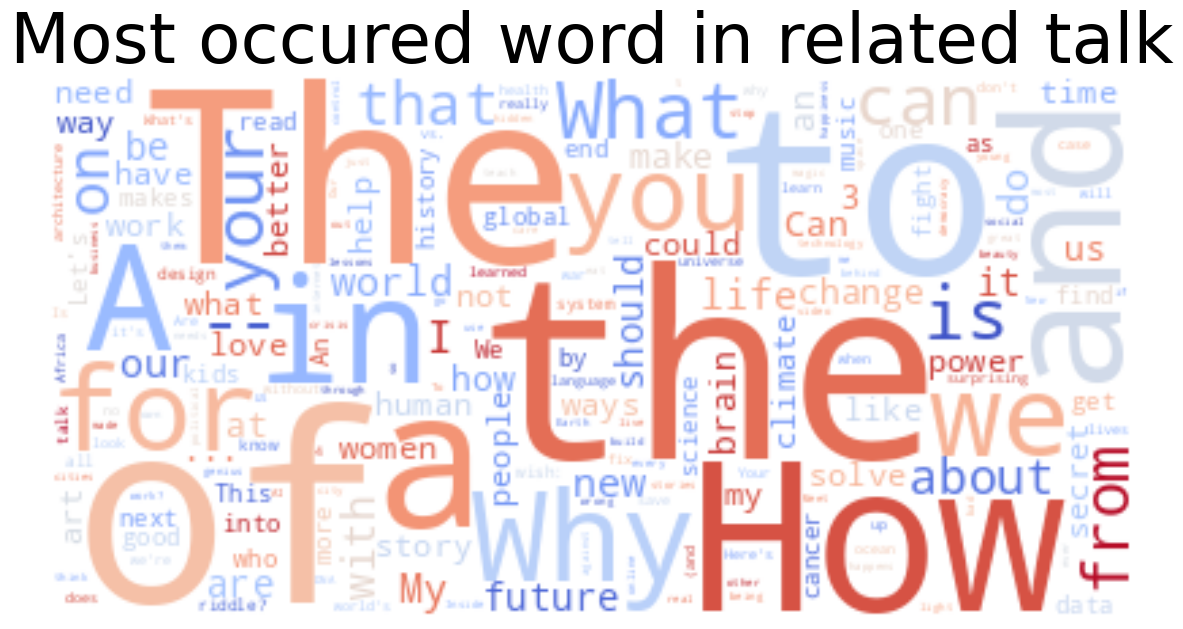

In [137]:
# Chart - 2 visualization code
words = []
for value in df.related_talks.values:
  for i in eval(value).values():
    for j in i.split():
      words.append(j)

wc = pd.Series(words).value_counts()

# Generate the word cloud with the custom mask
wordcloud = WordCloud(background_color='white',colormap='coolwarm' ).generate_from_frequencies(wc)
plt.figure(figsize=(14, 25))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most occured word in related talk', fontdict={'size': 50})
plt.axis('off');

##### 1. **Why did you pick the specific chart?**
  - related talk column having all string values.
  - and these string values are individual.
  - So, converting these values using column encoding will not work.
  - Thats why WordCloud is best chart for this data.

##### **2. What is/are the insight(s) found from the chart?**
  - of, the, to, how, for these are the most occured words.

##### **3. Will the gained insights help creating a positive business impact?**
  - No


### **Chart - 3**

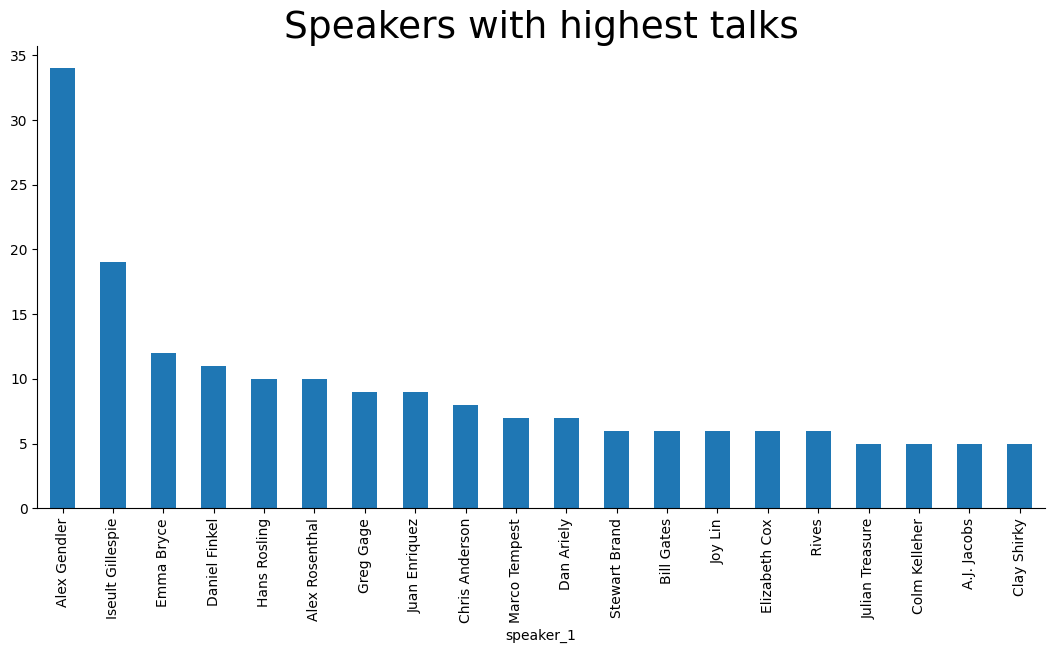

In [138]:
# Chart - 3 visualization code
plt.figure(figsize=(13,6))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.title('Speakers with highest talks', fontdict={'size': 27})
df.speaker_1.value_counts()[:20].plot(kind='bar') ;

##### **1. Why did you pick the specific chart?**

  - I was trying to view speakers with highest count.
  - For this bar chart is perfect option.

##### **2. What is/are the insight(s) found from the chart?**

Following are the top 5 speakers, in which 3 speakers are from academics/authors.

1. Hans Rosling  - Swedish physician and academic

2. Juan Enríquez  - Mexican author

3. Greg Gage  - Neuroscientist & Researcher

4. Dan Ariely  - American professor and author

5. Marco Tempest  - Swiss magician


### **Chart - 4**

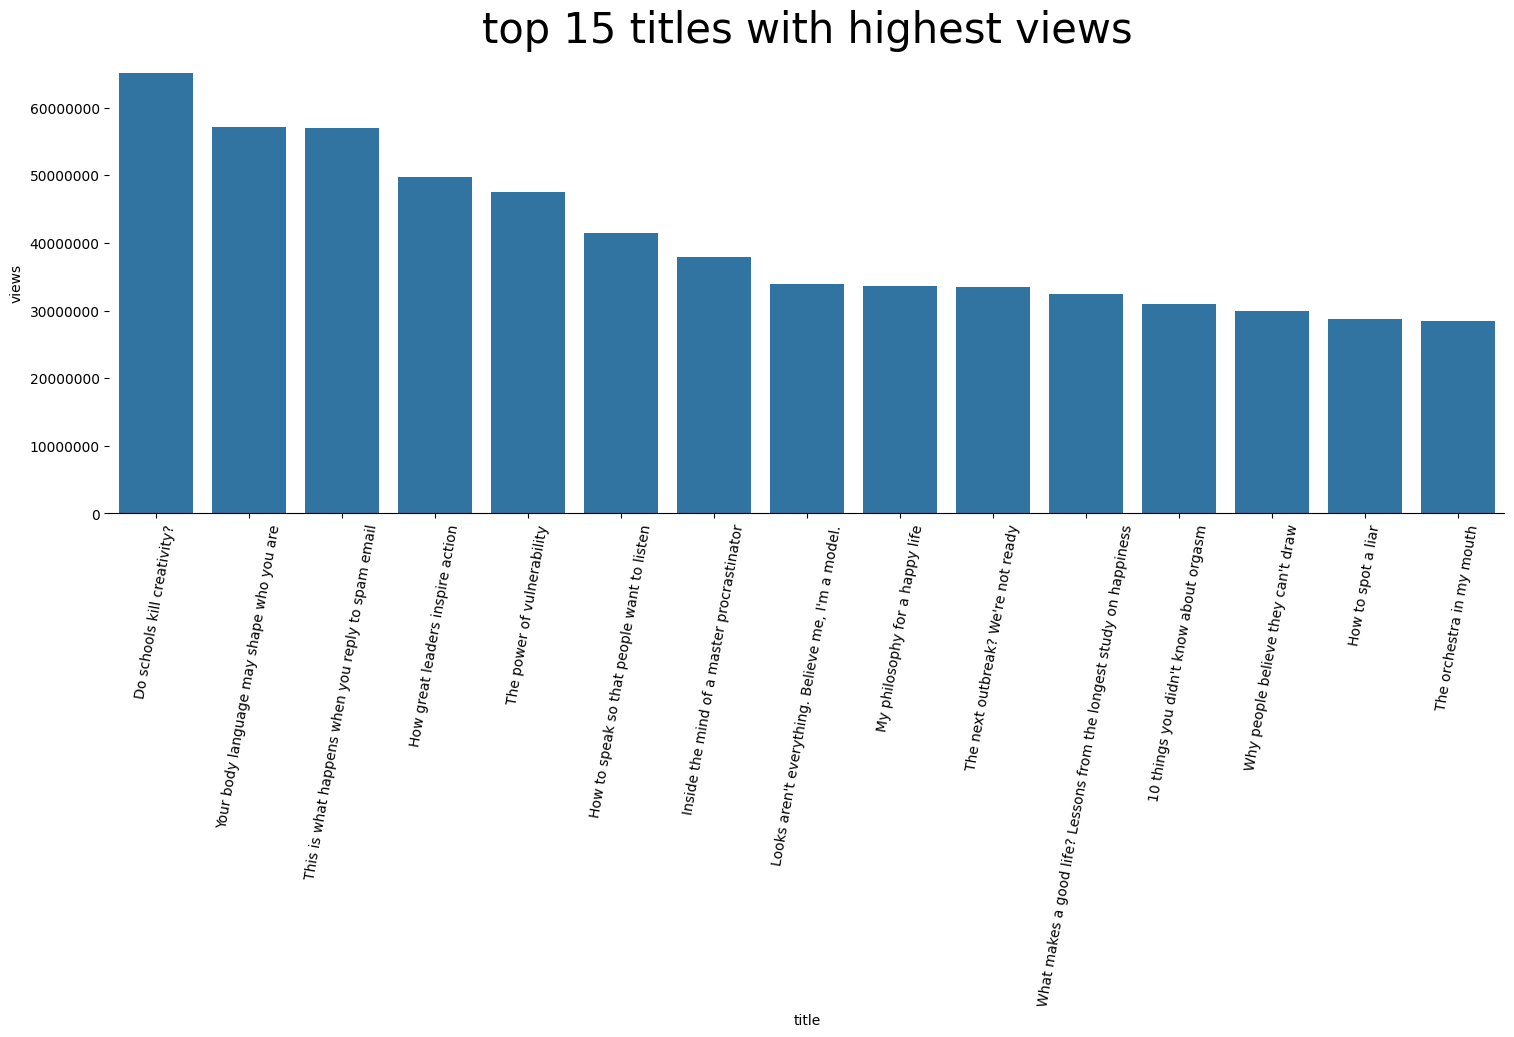

In [139]:
# Chart - 4 visualization code
from matplotlib.ticker import ScalarFormatter
top_15_titles = df.sort_values(by='views', ascending=False).head(15)[['title', 'views']]
plt.figure(figsize=(18,6))

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
plt.ticklabel_format(style='plain', axis='y')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.xticks(rotation=80,)
plt.title('top 15 titles with highest views', fontdict={'size': 30})
sns.barplot(x='title', y= 'views', data=top_15_titles) ;

##### **1. Why did you pick the specific chart?**

  - To visualize view count of the top 15 titles, bar chart is the best option.

##### **2. What is/are the insight(s) found from the chart?**

  - Do schools kill creativity is the really good topic viewed more in talks.
  - Second most viewed topic is about spam mails, it is useful in todays technological world.

### **Chart - 5**

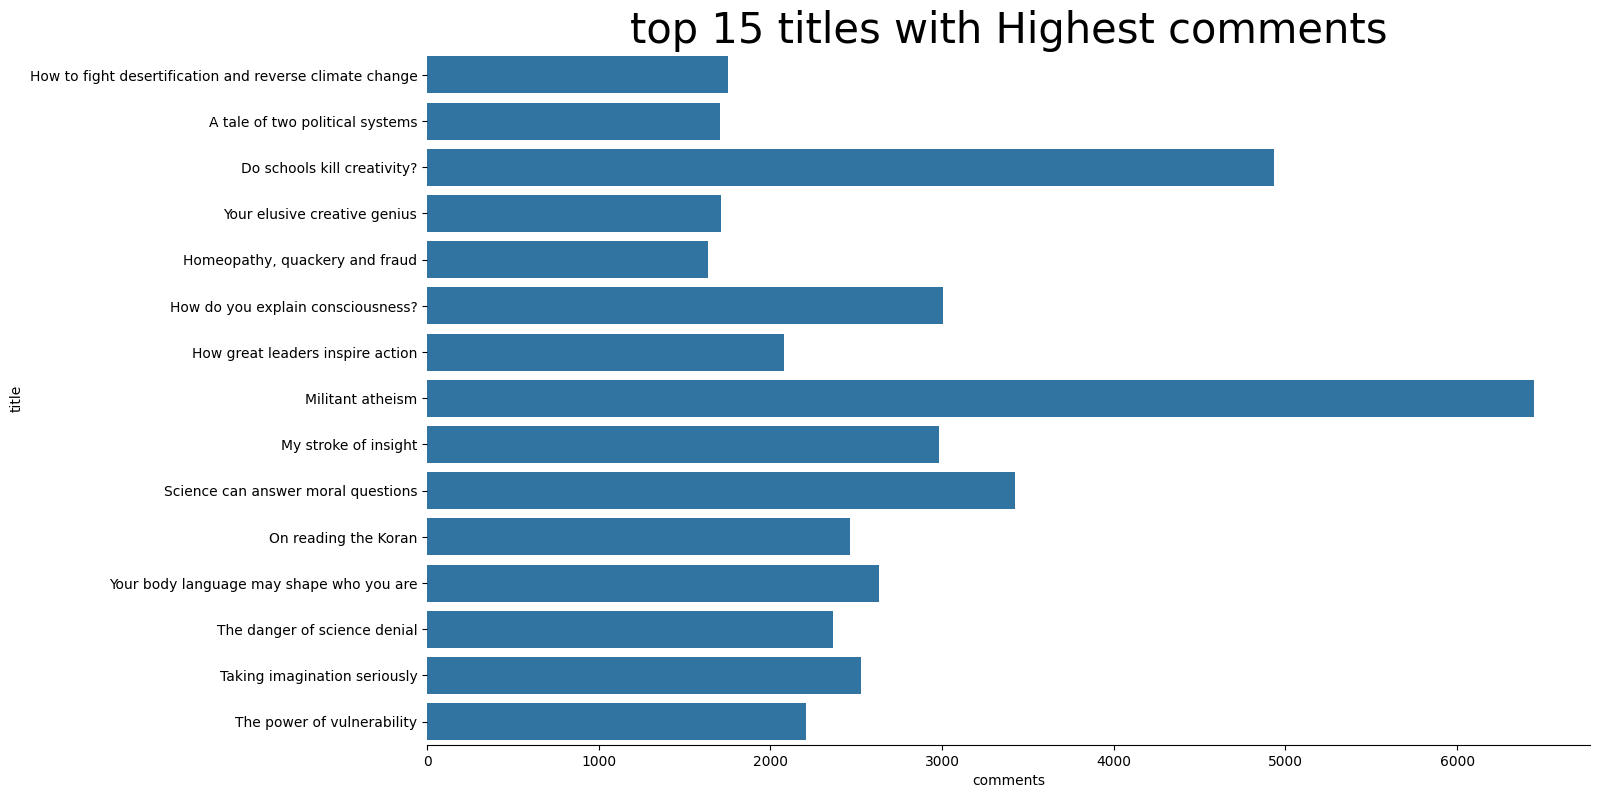

In [140]:

top_10_titles = df.sort_values(by='comments', ascending=False).head(15).sample(15)[['title', 'comments']]
plt.figure(figsize=(15,9))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.title('top 15 titles with Highest comments', fontdict={'size': 30})
sns.barplot(y='title', x= 'comments', data=top_10_titles) ;

##### **1. Why did you pick the specific chart?**

 - To visualize data like frequency count, bar chart is good option.

##### **2. What is/are the insight(s) found from the chart?**

  - militant atheism
  - Do school kill creativity?
  - Science can answer moral questions

Are the top title with highest comments.

##### **3. Will the gained insights help creating a positive business impact?**
Are there any insights that lead to negative growth? Justify with specific reason.

  - A tale of two political system having least comments.
  - it means peoples are less interested in politics.


### **Chart - 6**

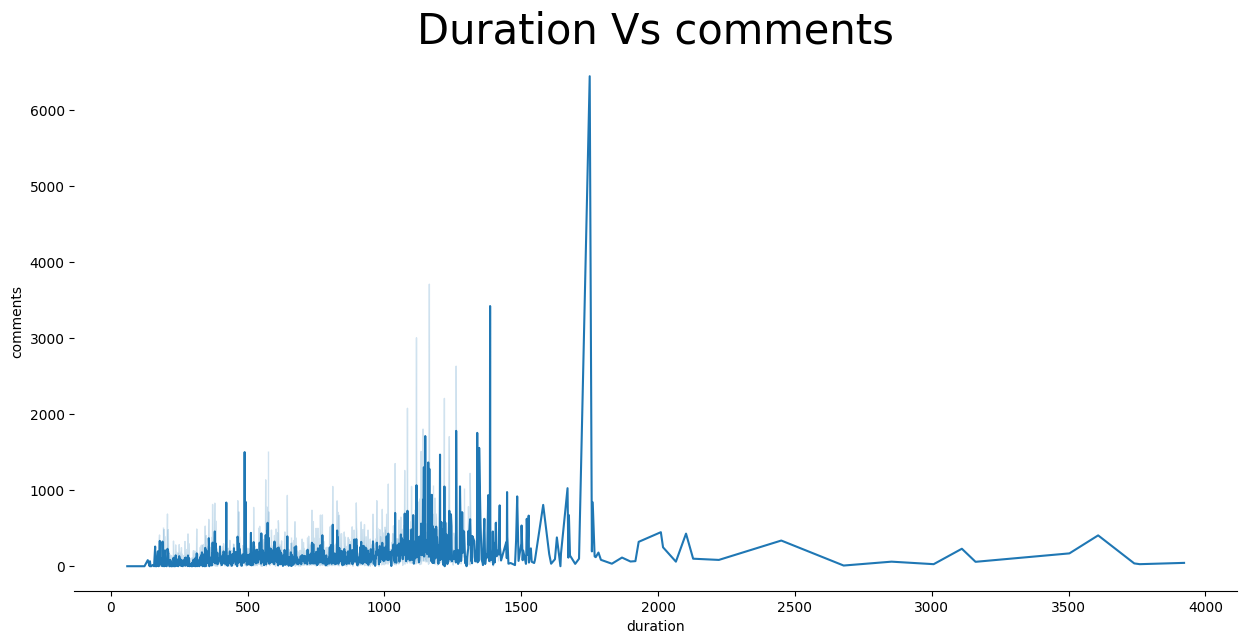

In [141]:
plt.figure(figsize=(15,7))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.title('Duration Vs comments', fontdict={'size': 30})
sns.lineplot(x='duration', y='comments', data=df);

##### **1. Why did you pick the specific chart?**

  - Both the values from Duration column and Comment columns are nemerical. Thats why this chart is selected.

##### **2. What is/are the insight(s) found from the chart?**

  - Comments density is higher when duration is between around 200 and 1500.
  - comments density is lower when duration is greater than around 1800.

### **Chart - 7**

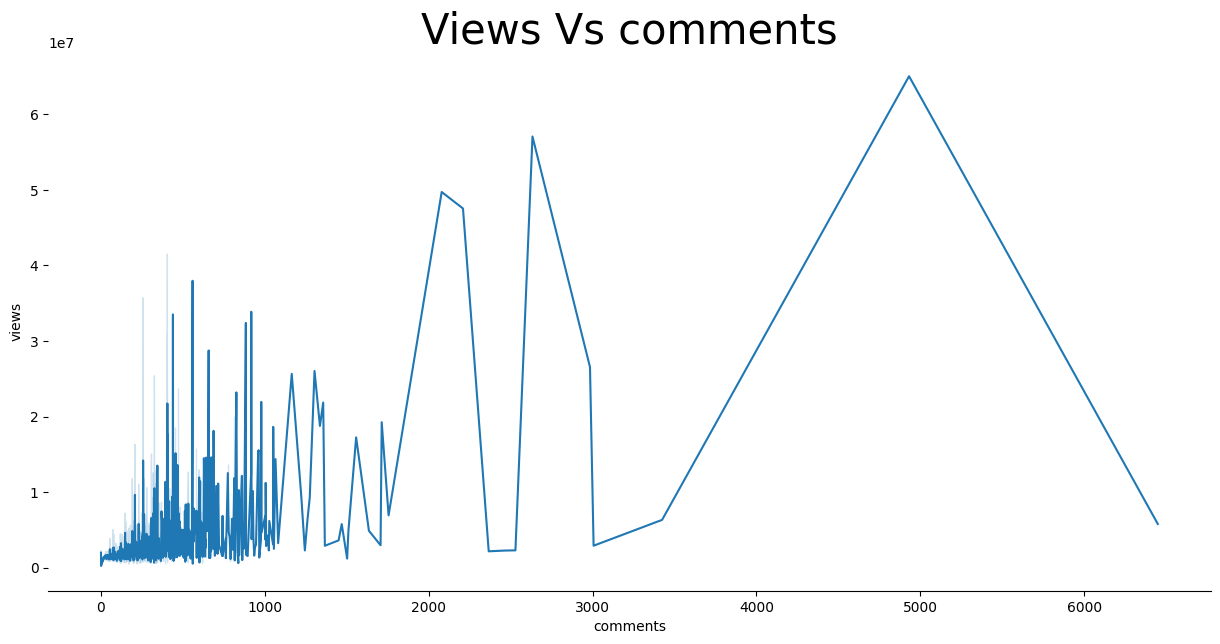

In [142]:
plt.figure(figsize=(15,7))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.title('Views Vs comments', fontdict={'size': 30})
sns.lineplot(x='comments', y='views', data=df);

##### **1. Why did you pick the specific chart?**

  - Both the columns having linear relation  thats why picked this chart.

##### **2. What is/are the insight(s) found from the chart?**

High Variability in Comments for Lower View Counts
  - In the lower range of views (0 - 10 million), the number of comments fluctuates significantly. Some videos with similar views have vastly different comment counts, suggesting that engagement varies based on content type or audience interest.

Outliers with Unusually High Comments
  - There are a few extreme spikes where the number of comments is disproportionately high compared to surrounding data points. This might indicate viral content, controversial topics, or highly engaging discussions.

Steady Increase in Comments for Higher Views
  - As the view count increases beyond 10 million, the comment count generally trends upward, indicating that higher viewership typically leads to more engagement. However, there are still fluctuations, meaning not all high-view videos receive consistent engagement.

Sudden Drop-Offs and Gaps in Data
  - Some sections of the graph show abrupt drops in comments despite increasing views. This could be due to platform-specific factors like disabled comments, less engaging content, or differences in audience behavior.

##### **3. Will the gained insights help creating a positive business impact?**

Yes, the insights from this graph can help drive positive business impact in several ways, particularly in content strategy, audience engagement, and monetization. Here’s how:

1. Optimizing Content Strategy
2. Enhancing Audience Engagement
3. Improving Monetization Strategies
4. Predicting Trends & Reducing Inefficiencies

### **Chart - 8**

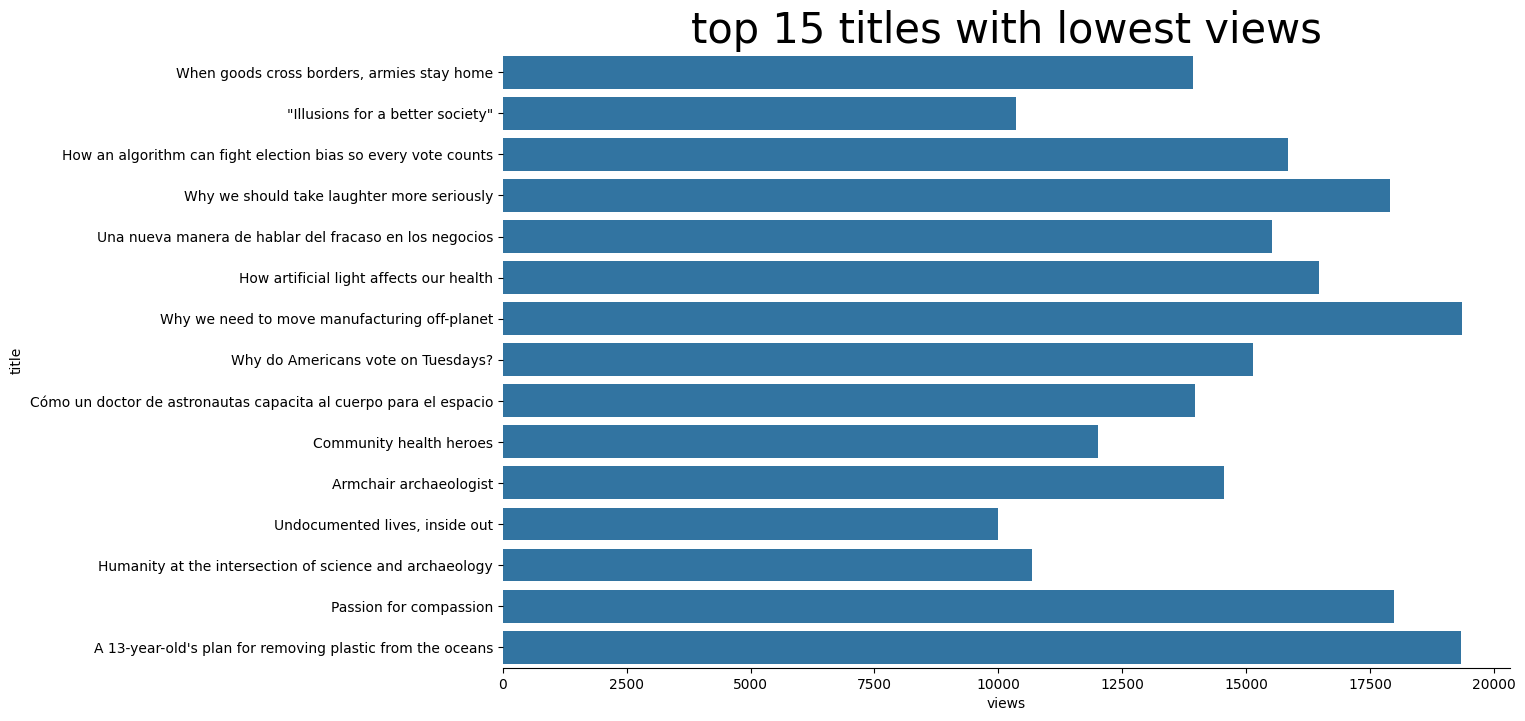

In [143]:
top_15_titles = df.sort_values(by='views', ascending=True).head(15).sample(15)[['title', 'views']]
plt.figure(figsize=(13,8))
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.title('top 15 titles with lowest views', fontdict={'size': 30})
sns.barplot(y='title', x= 'views', data=top_15_titles) ;

##### **1. Why did you pick the specific chart?**

  - To visualize top 15 title with lowest view bar chart is good.

## **Chart - 14 - Correlation Heatmap**

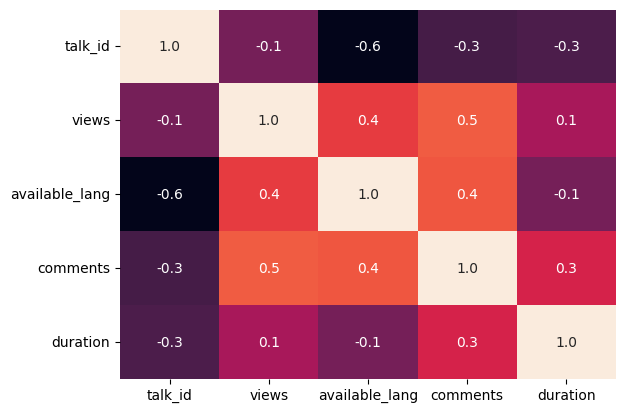

In [144]:
# Correlation Heatmap visualization code
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.1f', cbar=False) ;

##### **1. Why did you pick the specific chart?**

  - heatmap is widely used to see correlation.

## **Chart - 15 - Pair Plot**

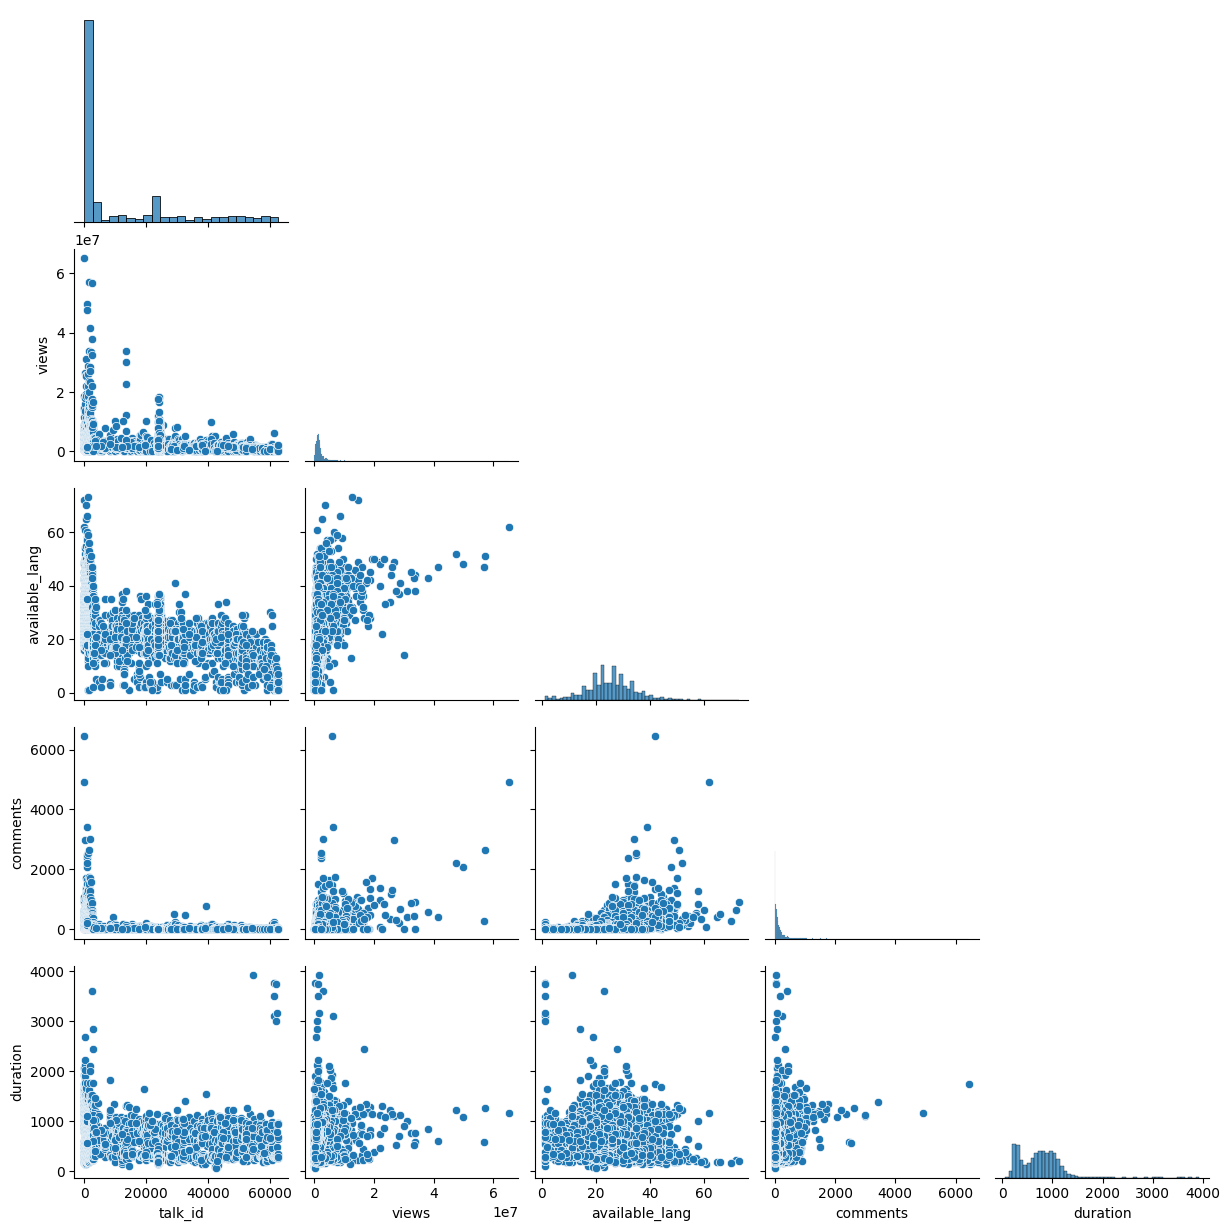

In [145]:
# Pair Plot visualization code
sns.pairplot(df,corner=True);

##### **1. Why did you pick the specific chart?**
  - Pairplot used to see relation between different columns of dataframe.

---
---

## **Data preprocessing**

### **drop unnecessary columns**

In [147]:
df.drop(columns=['talk_id', 'transcript'], inplace=True)

### **Define binary classes: Low = 0, High = 1**


In [148]:
q_low = df['views'].quantile(0.33)
q_high = df['views'].quantile(0.66)
df_binary = df[(df['views'] <= q_low) | (df['views'] > q_high)].copy()
df_binary['popularity'] = (df_binary['views'] > q_high).astype(int)


### **Feature engineering**

In [149]:
df_binary['publish_delay_days']    = (df_binary['published_date'] - df_binary['recorded_date']).dt.days.fillna(0)
df_binary['description_length']    = df_binary['description'].str.len()
df_binary['title_length']          = df_binary['title'].str.len()
df_binary['about_speakers_length'] = df_binary['about_speakers'].str.len()
df_binary['num_topics']            = df_binary['topics'].apply(lambda x: len(eval(x)) if pd.notnull(x) else 0)
df_binary['duration_x_description'] = df_binary['duration'] * df_binary['description_length']
df_binary['topics_x_title']         = df_binary['num_topics'] * df_binary['title_length']


### **Encode categorical features**

In [150]:
cat_features = ['speaker_1','occupations','event','native_lang']
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_binary[cat_features] = enc.fit_transform(df_binary[cat_features])

### **Numerical features**

In [151]:
num_feats_binary = df_binary[[
    'comments','duration','speaker_1','occupations','event','native_lang',
    'publish_delay_days','description_length','title_length',
    'about_speakers_length','num_topics','duration_x_description','topics_x_title'
]].values

### **Sentence embeddings**

In [152]:
model_name = 'all-MiniLM-L6-v2'
st_model = SentenceTransformer(model_name)
desc_emb_binary    = st_model.encode(df_binary['description'].tolist(), show_progress_bar=True)
title_emb_binary   = st_model.encode(df_binary['title'].tolist(), show_progress_bar=True)
speaker_emb_binary = st_model.encode(df_binary['about_speakers'].tolist(), show_progress_bar=True)


Batches:   0%|          | 0/84 [00:00<?, ?it/s]

Batches:   0%|          | 0/84 [00:00<?, ?it/s]

Batches:   0%|          | 0/84 [00:00<?, ?it/s]

### **Combine features**

In [153]:
X = hstack([
    csr_matrix(num_feats_binary),
    csr_matrix(desc_emb_binary),
    csr_matrix(title_emb_binary),
    csr_matrix(speaker_emb_binary)
])
y = df_binary['popularity'].values


### **Train/test split**

In [154]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### **Model: LightGBM (or stacked)**

In [155]:
model = LGBMClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Number of positive: 1088, number of negative: 1056
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.030119 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 296379
[LightGBM] [Info] Number of data points in the train set: 2144, number of used features: 1165
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.507463 -> initscore=0.029853
[LightGBM] [Info] Start training from score 0.029853


### **Evaluation**

In [156]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Low", "High"]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8227611940298507

Classification Report:
               precision    recall  f1-score   support

         Low       0.82      0.83      0.82       264
        High       0.83      0.82      0.82       272

    accuracy                           0.82       536
   macro avg       0.82      0.82      0.82       536
weighted avg       0.82      0.82      0.82       536


Confusion Matrix:
 [[218  46]
 [ 49 223]]


# **Logistic Regression for TED Talk Popularity (Binary)**

### **Prepare features and target from earlier steps**

In [157]:
X = hstack([
    csr_matrix(num_feats_binary),
    csr_matrix(desc_emb_binary),
    csr_matrix(title_emb_binary),
    csr_matrix(speaker_emb_binary)
])
y = df_binary['popularity'].values

### **Train/Test Split**

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

### **Logistic Regression Model**

In [159]:
lr_model = LogisticRegression(max_iter=1000, solver='lbfgs', n_jobs=-1)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

### **Predict and Evaluate**

In [160]:
y_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Low", "High"]))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7014925373134329

Classification Report:
               precision    recall  f1-score   support

         Low       0.67      0.78      0.72       264
        High       0.75      0.62      0.68       272

    accuracy                           0.70       536
   macro avg       0.71      0.70      0.70       536
weighted avg       0.71      0.70      0.70       536


Confusion Matrix:
 [[206  58]
 [102 170]]


# **E N D**